# EDA — EEG por Estímulo Emocional

In [ ]:
import ray, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA = ("/Volumes/Externo4T/GoogleDrive/Tesistas Neurodatos/"
        "Datos  Crudos/EEG/EEG por Estímulo/Estímulos Emocionales")
FS         = 125
SAT_THRESH = 90_000

ray.init("ray://localhost:10001")
print(ray.cluster_resources())

In [22]:
def _leer_csv(path):
    """Lee el CSV detectando el nº de columnas desde la primera línea."""
    import pandas as pd
    with open(path, 'r', errors='replace') as f:
        primera = f.readline()
    n_cols = len(primera.strip().split(','))
    # Estructura: SampleIndex + hasta 16 EEG + extras (Accel etc.) + Estimulo
    n_eeg   = min(16, n_cols - 2)
    n_extra = n_cols - 2 - n_eeg
    nombres = (["SampleIndex"] +
               [f"EXG Channel {i}" for i in range(n_eeg)] +
               [f"Extra{i}" for i in range(n_extra)] +
               ["Estimulo"])
    return pd.read_csv(path, header=None, names=nombres, skipinitialspace=True)


@ray.remote
def listar(ruta):
    import os, re
    return sorted(f for f in os.listdir(ruta)
                  if re.match(r"P\d+_Estimulo_\d+\.csv", f))

@ray.remote
def stats(ruta, nombre, sat_thresh, fs):
    import os, re, numpy as np, pandas as pd
    path = os.path.join(ruta, nombre)
    m    = re.match(r"P(\d+)_Estimulo_(\d+)\.csv", nombre)
    pid, est = int(m.group(1)), int(m.group(2))
    try:
        with open(path, 'r', errors='replace') as f:
            primera = f.readline()
        n_cols  = len(primera.strip().split(','))
        n_eeg   = min(16, n_cols - 2)
        n_extra = n_cols - 2 - n_eeg
        nombres = (["SampleIndex"] +
                   [f"EXG Channel {i}" for i in range(n_eeg)] +
                   [f"Extra{i}" for i in range(n_extra)] +
                   ["Estimulo"])
        eeg_cols = [f"EXG Channel {i}" for i in range(n_eeg)]
        df  = pd.read_csv(path, header=None, names=nombres, skipinitialspace=True)
        sat = {c: float((pd.to_numeric(df[c], errors='coerce').abs() > sat_thresh).mean() * 100)
               for c in eeg_cols}
        good = [c for c, v in sat.items() if v < 1]
        return {
            "participante": pid, "estimulo": est, "n_cols": n_cols,
            "n_muestras": len(df), "duracion_s": len(df) / fs,
            "n_sat_ch": sum(v == 100 for v in sat.values()),
            "mean_amp": float(df[good].apply(pd.to_numeric, errors='coerce').stack().mean()) if good else float("nan"),
        }
    except Exception as e:
        return {"participante": pid, "estimulo": est, "error": str(e)}

@ray.remote
def psd(ruta, nombre, sat_thresh, fs):
    import os, re, numpy as np, pandas as pd
    path = os.path.join(ruta, nombre)
    m    = re.match(r"P(\d+)_Estimulo_(\d+)\.csv", nombre)
    pid, est = int(m.group(1)), int(m.group(2))

    def welch_np(sig, fs, nperseg):
        window = np.hanning(nperseg)
        hop    = nperseg // 2
        freqs  = np.fft.rfftfreq(nperseg, d=1.0 / fs)
        scale  = fs * (window ** 2).sum()
        segs, i = [], 0
        while i + nperseg <= len(sig):
            chunk = sig[i:i + nperseg] * window
            segs.append(np.abs(np.fft.rfft(chunk)) ** 2 / scale)
            i += hop
        return freqs, np.mean(segs, axis=0) if segs else (freqs, np.zeros_like(freqs))

    try:
        with open(path, 'r', errors='replace') as f:
            primera = f.readline()
        n_cols  = len(primera.strip().split(','))
        n_eeg   = min(16, n_cols - 2)
        n_extra = n_cols - 2 - n_eeg
        nombres = (["SampleIndex"] +
                   [f"EXG Channel {i}" for i in range(n_eeg)] +
                   [f"Extra{i}" for i in range(n_extra)] +
                   ["Estimulo"])
        eeg_cols = [f"EXG Channel {i}" for i in range(n_eeg)]
        df = pd.read_csv(path, header=None, names=nombres, skipinitialspace=True)
        buenos = [
            c for c in eeg_cols if c in df.columns
            and (pd.to_numeric(df[c], errors='coerce').abs() > sat_thresh).mean() * 100 < 50
        ]
        if not buenos:
            return {"participante": pid, "estimulo": est, "freqs": None, "psd": None}
        nperseg = fs * 4
        psds = []
        for c in buenos:
            sig = pd.to_numeric(df[c], errors='coerce').dropna().values.astype(float)
            if len(sig) >= nperseg:
                f_arr, p = welch_np(sig, fs, nperseg)
                psds.append(p)
        if not psds:
            return {"participante": pid, "estimulo": est, "freqs": None, "psd": None}
        return {"participante": pid, "estimulo": est,
                "freqs": f_arr.tolist(), "psd": np.mean(psds, axis=0).tolist()}
    except Exception as e:
        return {"participante": pid, "estimulo": est, "freqs": None, "psd": None, "error": str(e)}

In [23]:
from ray.util.scheduling_strategies import NodeAffinitySchedulingStrategy

@ray.remote
def check_nodo(ruta):
    import os, ray
    return {
        "node_id": ray.get_runtime_context().get_node_id(),
        "tiene_disco": os.path.exists(ruta),
    }

# Probar cada nodo explícitamente por IP
recursos = ray.cluster_resources()
ips = [k.split("node:")[1] for k in recursos
       if k.startswith("node:") and "__internal_head__" not in k]
print("Nodos en el cluster:", ips)

checks = ray.get([
    check_nodo.options(resources={f"node:{ip}": 0.001}).remote(RUTA)
    for ip in ips
])
for ip, c in zip(ips, checks):
    print(f"  {ip} → disco: {c['tiene_disco']}")

nodo_disco = next((c["node_id"] for c in checks if c["tiene_disco"]), None)
if nodo_disco is None:
    raise RuntimeError("Ningún nodo tiene el disco montado.")
print(f"\nNodo fijado: {nodo_disco}")

ESTRATEGIA = NodeAffinitySchedulingStrategy(node_id=nodo_disco, soft=False)

archivos = ray.get(listar.options(scheduling_strategy=ESTRATEGIA).remote(RUTA))
print(f"{len(archivos)} archivos encontrados")

Nodos en el cluster: ['10.23.17.56', '10.23.17.54', '10.23.17.55', '10.23.17.53']
  10.23.17.56 → disco: False
  10.23.17.54 → disco: False
  10.23.17.55 → disco: False
  10.23.17.53 → disco: True

Nodo fijado: 3c5ead7664a82e94c7337748995d516b394d0c9302621616a5c37251
1778 archivos encontrados


In [24]:
res_stats = ray.get([
    stats.options(scheduling_strategy=ESTRATEGIA).remote(RUTA, a, SAT_THRESH, FS)
    for a in archivos
])
res_psd = ray.get([
    psd.options(scheduling_strategy=ESTRATEGIA).remote(RUTA, a, SAT_THRESH, FS)
    for a in archivos
])

meta = pd.DataFrame([r for r in res_stats if "error" not in r])
meta = meta.sort_values(["participante", "estimulo"]).reset_index(drop=True)

BANDS = {"Delta":(1,4), "Theta":(4,8), "Alpha":(8,13), "Beta":(13,30), "Gamma":(30,45)}
band_rows = []
for r in res_psd:
    row = {"participante": r["participante"], "estimulo": r["estimulo"]}
    if r["freqs"]:
        freqs, p = np.array(r["freqs"]), np.array(r["psd"])
        for b, (lo, hi) in BANDS.items():
            mask = (freqs >= lo) & (freqs <= hi)
            row[b] = float(np.trapz(p[mask], freqs[mask])) if mask.any() else np.nan
    band_rows.append(row)
band_df = pd.DataFrame(band_rows)

errores = [r for r in res_stats if "error" in r]
print(f"OK: {len(meta)}  errores: {len(errores)}")
if errores:
    print("Errores:", errores[:3])
meta.head()

OK: 1778  errores: 0


,participante,estimulo,n_cols,n_muestras,duracion_s,n_sat_ch,mean_amp
0,7,1,21,615,4.92,0,-10940.927156
1,7,2,21,615,4.92,0,-10825.923794
2,7,3,21,615,4.92,0,-10605.160211
3,7,4,21,615,4.92,0,-9470.539957
4,7,5,21,615,4.92,0,-9695.191395


/var/folders/hq/yps3w2v12m9c6b7cwkl1lzg40000gn/T/ipykernel_99823/3276018011.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=estims, showfliers=False, patch_artist=True,
/var/folders/hq/yps3w2v12m9c6b7cwkl1lzg40000gn/T/ipykernel_99823/3276018011.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_ab, labels=estims, showfliers=False, patch_artist=True,


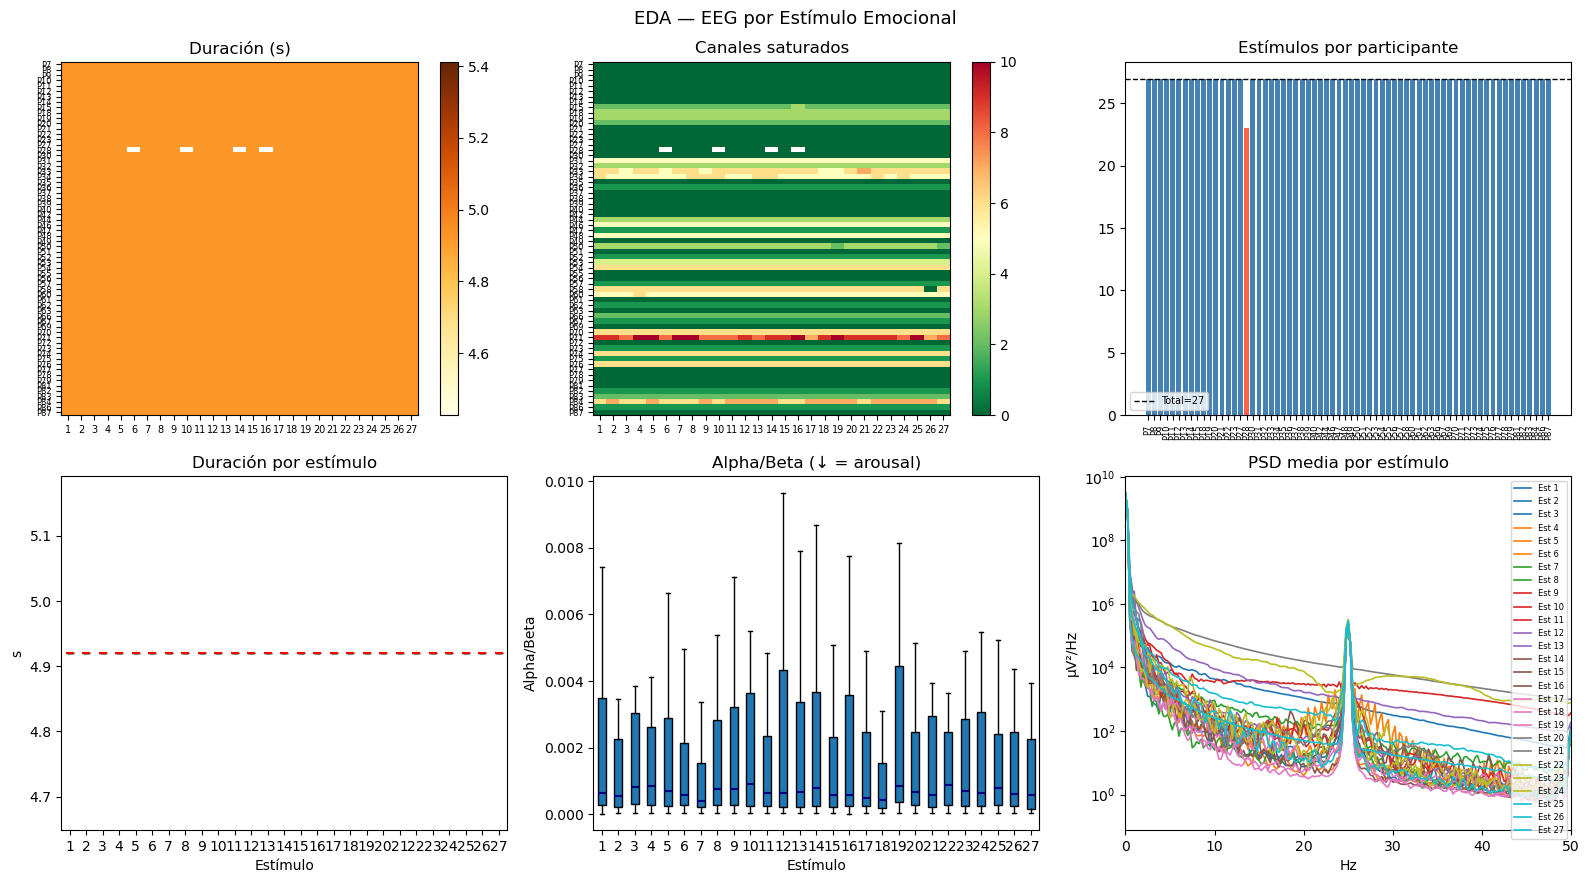

Guardado: eda_estimulos.png


In [25]:
estims  = sorted(meta["estimulo"].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Heatmap duración
ax = axes[0, 0]
piv = meta.pivot_table(index="participante", columns="estimulo", values="duracion_s")
im = ax.imshow(piv.values, aspect="auto", cmap="YlOrBr")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, fontsize=7)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels([f"P{p}" for p in piv.index], fontsize=6)
plt.colorbar(im, ax=ax); ax.set_title("Duración (s)")

# 2. Heatmap canales saturados
ax = axes[0, 1]
piv2 = meta.pivot_table(index="participante", columns="estimulo", values="n_sat_ch")
im2 = ax.imshow(piv2.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(len(piv2.columns))); ax.set_xticklabels(piv2.columns, fontsize=7)
ax.set_yticks(range(len(piv2.index)));   ax.set_yticklabels([f"P{p}" for p in piv2.index], fontsize=6)
plt.colorbar(im2, ax=ax); ax.set_title("Canales saturados")

# 3. Completitud
ax = axes[0, 2]
comp = meta.groupby("participante")["estimulo"].nunique()
n_tot = len(estims)
ax.bar([f"P{p}" for p in comp.index], comp.values,
       color=["tomato" if v < n_tot else "steelblue" for v in comp.values])
ax.axhline(n_tot, color="k", ls="--", lw=1, label=f"Total={n_tot}")
ax.legend(fontsize=7); ax.set_title("Estímulos por participante")
ax.tick_params(axis="x", rotation=90, labelsize=6)

# 4. Boxplot duración por estímulo
ax = axes[1, 0]
data = [meta[meta["estimulo"] == e]["duracion_s"].values for e in estims]
ax.boxplot(data, labels=estims, showfliers=False, patch_artist=True,
           medianprops=dict(color="red", lw=1.5))
ax.set_xlabel("Estímulo"); ax.set_ylabel("s"); ax.set_title("Duración por estímulo")

# 5. Alpha/Beta ratio
ax = axes[1, 1]
band_df["a_b"] = band_df["Alpha"] / band_df["Beta"].replace(0, np.nan)
data_ab = [band_df[band_df["estimulo"] == e]["a_b"].dropna().values for e in estims]
ax.boxplot(data_ab, labels=estims, showfliers=False, patch_artist=True,
           medianprops=dict(color="navy", lw=1.5))
ax.set_xlabel("Estímulo"); ax.set_ylabel("Alpha/Beta"); ax.set_title("Alpha/Beta (↓ = arousal)")

# 6. PSD media por estímulo
ax = axes[1, 2]
psd_by_e = {}
for r in res_psd:
    if r["freqs"]:
        psd_by_e.setdefault(r["estimulo"], []).append(np.array(r["psd"]))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(psd_by_e), 1)))
freqs_ref = np.array(next(r["freqs"] for r in res_psd if r["freqs"]))
for i, (e, psds) in enumerate(sorted(psd_by_e.items())):
    ax.semilogy(freqs_ref, np.mean(psds, axis=0), color=cmap[i % len(cmap)], lw=1.2, label=f"Est {e}")
ax.set_xlim(0, 50); ax.set_xlabel("Hz"); ax.set_ylabel("µV²/Hz")
ax.set_title("PSD media por estímulo"); ax.legend(fontsize=6)

plt.suptitle("EDA — EEG por Estímulo Emocional", fontsize=13)
plt.tight_layout()
plt.savefig("eda_estimulos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: eda_estimulos.png")

In [26]:
print(f"Participantes : {meta['participante'].nunique()}")
print(f"Estímulos     : {meta['estimulo'].nunique()} → {estims}")
print(f"Archivos OK   : {len(meta)}")
print(f"Duración media: {meta['duracion_s'].mean():.1f} s (±{meta['duracion_s'].std():.1f})")
print(f"Con saturación: {(meta['n_sat_ch'] > 0).sum()} archivos")
print()
print("Potencia mediana por banda:")
for b in BANDS:
    if b in band_df.columns:
        print(f"  {b:7s}: {band_df[b].median():.3e} µV²")

Participantes : 66
Estímulos     : 27 → [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Archivos OK   : 1778
Duración media: 4.9 s (±0.0)
Con saturación: 890 archivos

Potencia mediana por banda:
  Delta  : 4.400e+02 µV²
  Theta  : 4.783e+01 µV²
  Alpha  : 2.512e+01 µV²
  Beta   : 5.079e+04 µV²
  Gamma  : 1.530e+01 µV²


2026-07-05 05:00:07,619	WARNING dataclient.py:403 -- Encountered connection issues in the data channel. Attempting to reconnect.
2026-07-05 05:00:22,440	ERROR dataclient.py:330 -- Unrecoverable error in data channel.
